In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import xarray as xr

# Update this path to where you saved the file in Drive
file_path = '/content/drive/MyDrive/IMD_Project/India_Meteo_Combined_Final.nc'

# Use 'chunks' to enable Dask (Lazy Loading)
ds = xr.open_dataset(file_path, chunks={'time': 500})

print(ds)

<xarray.Dataset> Size: 9GB
Dimensions:  (time: 27029, lat: 129, lon: 135)
Coordinates:
  * time     (time) datetime64[ns] 216kB 1951-01-01 1951-01-02 ... 2024-12-31
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
Data variables:
    rain     (time, lat, lon) float32 2GB dask.array<chunksize=(500, 26, 27), meta=np.ndarray>
    tmax     (time, lat, lon) float64 4GB dask.array<chunksize=(500, 19, 20), meta=np.ndarray>
    tmin     (time, lat, lon) float64 4GB dask.array<chunksize=(500, 19, 20), meta=np.ndarray>
Attributes:
    description:  Combined IMD Gridded Dataset (Rain, Tmax, Tmin)
    resolution:   0.25 x 0.25 degree
    history:      Created by Shivam Gupta - Multivariate Rainfall Prediction ...


/tmp/ipykernel_3686/470878541.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(file_path, chunks={'time': 500})


# Data Extraction & Feature Engineering (Kerala)

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Bounding box for Kerala (Approximate)
kerala_lat = slice(8.0, 12.8)
kerala_lon = slice(74.5, 77.5)

# Extract and take the mean across space (Lat/Lon) to get a 1D Time Series
print("Extracting Kerala state-wide average...")
ds_kerala = ds.sel(lat=kerala_lat, lon=kerala_lon).mean(dim=['lat', 'lon']).compute()
df = ds_kerala.to_dataframe().dropna()

# MULTIVARIATE FEATURE ENGINEERING ---
df['t_range'] = df['tmax'] - df['tmin']
df['rain_lag_1'] = df['rain'].shift(1)
# Cyclical Encoding for Seasonality (The 'Monsoon' Signal)
df['day_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365.25)
df = df.dropna()

# Select features for the "Gold Standard" model
features = ['rain', 'tmax', 'tmin', 't_range', 'rain_lag_1', 'day_sin', 'day_cos']
scaler = RobustScaler() # Handles rainfall outliers better than MinMaxScaler
scaled_data = scaler.fit_transform(df[features])

# SEQUENCE CREATION
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :])
        y.append(data[i+seq_length, 0]) # Target: rain
    return np.array(X), np.array(y)

SEQ_LENGTH = 30 # 30-day lookback window
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Time-series split (No Shuffling to prevent data leakage)
split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

Extracting Kerala state-wide average...


# The Hybrid CNN-LSTM Architecture

In [5]:
# MODEL BUILDING
model = Sequential([
    Input(shape=(SEQ_LENGTH, len(features))),

    # Feature Extraction (CNN)
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),

    # Sequence Learning (LSTM)
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.2),

    # Prediction Head
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(1)
])

# Use Huber Loss: it's a mix of MSE and MAE, perfect for handling heavy rain days
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='huber', metrics=['mae'])

# OPTIMIZATION CALLBACKS
callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# TRAINING
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 30s 64ms/step - loss: 0.1956 - mae: 0.4603 - val_loss: 0.1907 - val_mae: 0.4816 - learning_rate: 0.0010
Epoch 2/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 22s 66ms/step - loss: 0.1341 - mae: 0.3647 - val_loss: 0.1784 - val_mae: 0.4282 - learning_rate: 0.0010
Epoch 3/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - loss: 0.1243 - mae: 0.3453 - val_loss: 0.1696 - val_mae: 0.3936 - learning_rate: 0.0010
Epoch 4/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 24s 70ms/step - loss: 0.1201 - mae: 0.3349 - val_loss: 0.1670 - val_mae: 0.3858 - learning_rate: 0.0010
Epoch 5/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 39s 65ms/step - loss: 0.1167 - mae: 0.3299 - val_loss: 0.1707 - val_mae: 0.3973 - learning_rate: 0.0010
Epoch 6/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - loss: 0.1157 - mae: 0.3286 - val_loss: 0.1636 - val_mae: 0.3855 - learning_rate: 0.0010
Epoch 7/100
338/338 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - loss: 0.1147 - mae: 0.3245 - val_loss: 0.1649 - val_mae: 0.3821 - learnin

# Validation and Evaluation 

169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
Final Validation MAE: 2.67 mm


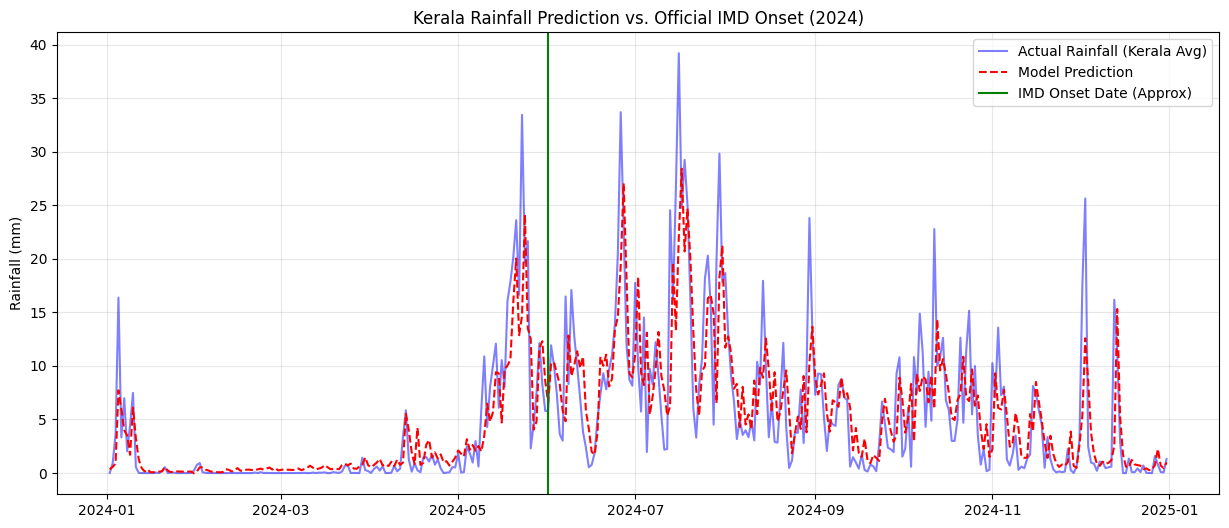

In [6]:
# PREDICTION & EVALUATION
y_pred_scaled = model.predict(X_val)

# Inverse transform to get actual Rainfall in mm
# (Multiplying back by the scaler's rainfall scale and adding the center)
y_val_mm = y_val * scaler.scale_[0] + scaler.center_[0]
y_pred_mm = y_pred_scaled.flatten() * scaler.scale_[0] + scaler.center_[0]

print(f"Final Validation MAE: {mean_absolute_error(y_val_mm, y_pred_mm):.2f} mm")

# Plot
plt.figure(figsize=(15, 6))
# Filter for 2024 (Last 365 days of the dataset)
plt.plot(df.index[-365:], y_val_mm[-365:], label='Actual Rainfall (Kerala Avg)', color='blue', alpha=0.5)
plt.plot(df.index[-365:], y_pred_mm[-365:], label='Model Prediction', color='red', linestyle='--')

# Highlight the Monsoon Start (Compare_IMD)
# Example: If June 1st was the onset
plt.axvline(pd.Timestamp('2024-06-01'), color='green', linestyle='-', label='IMD Onset Date (Approx)')

plt.title("Kerala Rainfall Prediction vs. Official IMD Onset (2024)")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Training Finished! ---
✅ Model successfully saved to Google Drive.

--- Model Performance Summary ---
Final Validation Loss (Huber): 0.1623
Final Validation MAE: 0.3850 mm
📊 Training plot saved to: /content/drive/MyDrive/IMD_Project/training_history_plot.png

MISSION COMPLETE: YOU CAN NOW SAFELY CLOSE COLAB.
ALL ASSETS ARE BACKED UP TO GOOGLE DRIVE.


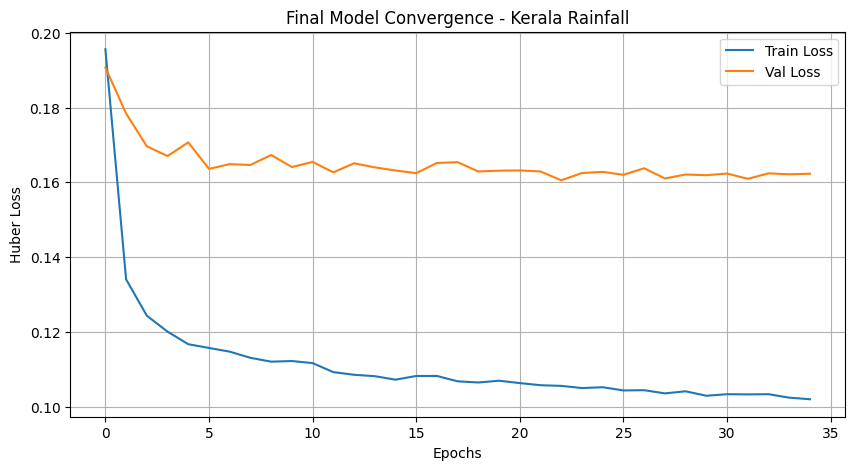

In [7]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

# DEFINE PATHS
# Ensure this matches the path where you saved your checkpoint
drive_model_path = '/content/drive/MyDrive/IMD_Project/best_kerala_model.keras'

# VERIFY AND SAVE
print("--- Training Finished! ---")
try:
    model.save('/content/drive/MyDrive/IMD_Project/kerala_model_final_complete.keras')
    print("✅ Model successfully saved to Google Drive.")
except Exception as e:
    print(f"⚠️ Could not save final model: {e}")

# GENERATE FINAL REPORT
print("\n--- Model Performance Summary ---")
history_dict = history.history
final_val_loss = history_dict['val_loss'][-1]
final_val_mae = history_dict['val_mae'][-1]

print(f"Final Validation Loss (Huber): {final_val_loss:.4f}")
print(f"Final Validation MAE: {final_val_mae:.4f} mm")

# PLOT AND SAVE ACCURACY GRAPH TO DRIVE
plt.figure(figsize=(10, 5))
plt.plot(history_dict['loss'], label='Train Loss')
plt.plot(history_dict['val_loss'], label='Val Loss')
plt.title('Final Model Convergence - Kerala Rainfall')
plt.xlabel('Epochs')
plt.ylabel('Huber Loss')
plt.legend()
plt.grid(True)

plot_path = '/content/drive/MyDrive/IMD_Project/training_history_plot.png'
plt.savefig(plot_path)
print(f"📊 Training plot saved to: {plot_path}")

# This prints a long string to keep the output stream 'active'
print("\n" + "="*50)
print("MISSION COMPLETE: YOU CAN NOW SAFELY CLOSE COLAB.")
print("ALL ASSETS ARE BACKED UP TO GOOGLE DRIVE.")
print("="*50)

In [11]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_squared_error

# Load the model (if your session restarted)
model = tf.keras.models.load_model('/content/drive/MyDrive/IMD_Project/kerala_model_final_complete.keras')

# Get predictions on the test/validation set
y_pred_scaled = model.predict(X_val)

# Inverse transform back to original rainfall (mm)
# Assuming 'scaler' is still in memory from your training cell
y_val_mm = y_val * scaler.scale_[0] + scaler.center_[0]
y_pred_mm = y_pred_scaled.flatten() * scaler.scale_[0] + scaler.center_[0]

mse = mean_squared_error(y_val_mm, y_pred_mm)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val_mm, y_pred_mm)

print(f"--- Final Robust Evaluation (Kerala) ---")
print(f"Validation MAE:  {mae:.2f} mm")
print(f"Validation RMSE: {rmse:.2f} mm")

print(f"RMSE/MAE Ratio: {rmse/mae:.2f}")

169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
--- Final Robust Evaluation (Kerala) ---
Validation MAE:  2.67 mm
Validation RMSE: 4.28 mm
RMSE/MAE Ratio: 1.60


--- Monthly Performance Breakdown (Kerala) ---
 Month Month_Name  MAE (mm)  RMSE (mm)  Sample_Days
     1    January      0.55       1.42          434
     2   February      0.46       1.13          396
     3      March      0.85       1.42          445
     4      April      1.95       2.98          450
     5        May      3.37       4.91          465
     6       June      4.23       5.72          450
     7       July      4.26       5.49          465
     8     August      4.15       5.62          465
     9  September      3.46       4.99          450
    10    October      3.80       5.35          465
    11   November      3.13       4.81          450
    12   December      1.38       2.61          465


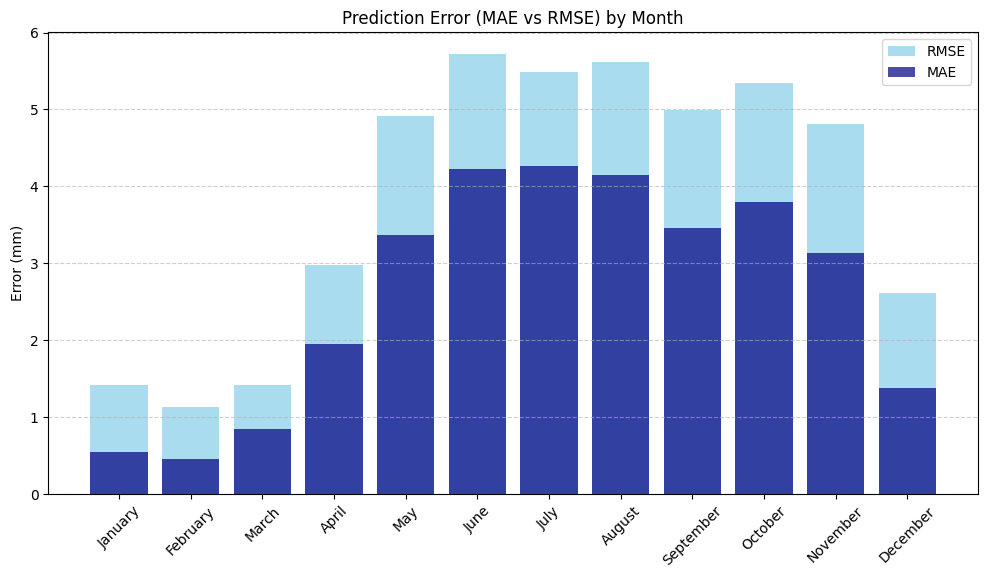

In [12]:
import pandas as pd

# Reconstruct the dates for the validation set
# We take the last 'len(y_val)' dates from the original dataframe index
val_dates = df.index[-len(y_val_mm):]

# Create a temporary Evaluation DataFrame
eval_df = pd.DataFrame({
    'Actual': y_val_mm,
    'Predicted': y_pred_mm
}, index=val_dates)

# Add a 'Month' column
eval_df['Month'] = eval_df.index.month

# Group by Month and calculate metrics
monthly_metrics = []

for month in range(1, 13):
    month_data = eval_df[eval_df['Month'] == month]

    if len(month_data) > 0:
        m_mae = mean_absolute_error(month_data['Actual'], month_data['Predicted'])
        m_mse = mean_squared_error(month_data['Actual'], month_data['Predicted'])
        m_rmse = np.sqrt(m_mse)

        monthly_metrics.append({
            'Month': month,
            'Month_Name': pd.to_datetime(month, format='%m').month_name(),
            'MAE (mm)': round(m_mae, 2),
            'RMSE (mm)': round(m_rmse, 2),
            'Sample_Days': len(month_data)
        })

# Convert to a clean DataFrame for display
monthly_eval_df = pd.DataFrame(monthly_metrics)
print("--- Monthly Performance Breakdown (Kerala) ---")
print(monthly_eval_df.to_string(index=False))

# MAE vs RMSE per Month
plt.figure(figsize=(12, 6))
plt.bar(monthly_eval_df['Month_Name'], monthly_eval_df['RMSE (mm)'], label='RMSE', color='skyblue', alpha=0.7)
plt.bar(monthly_eval_df['Month_Name'], monthly_eval_df['MAE (mm)'], label='MAE', color='navy', alpha=0.7)
plt.title('Prediction Error (MAE vs RMSE) by Month')
plt.ylabel('Error (mm)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

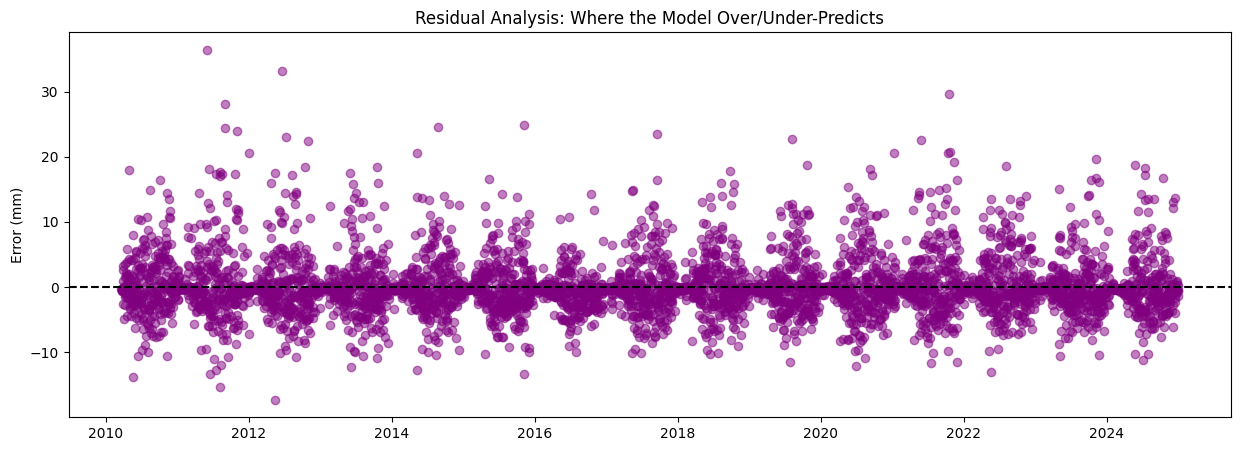

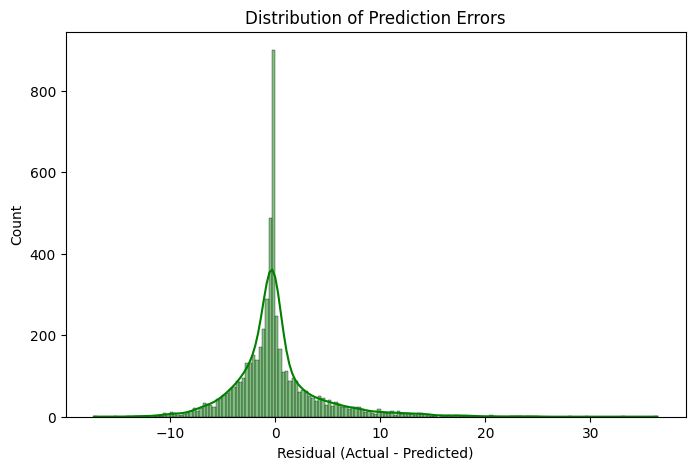

In [13]:
# Calculate Residuals
residuals = y_val_mm - y_pred_mm

# Plot Residuals over Time
plt.figure(figsize=(15, 5))
plt.scatter(df.index[-len(residuals):], residuals, alpha=0.5, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.title("Residual Analysis: Where the Model Over/Under-Predicts")
plt.ylabel("Error (mm)")
plt.show()

# Check for Bias: Histogram of Residuals
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='green')
plt.title("Distribution of Prediction Errors")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()

169/169 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step


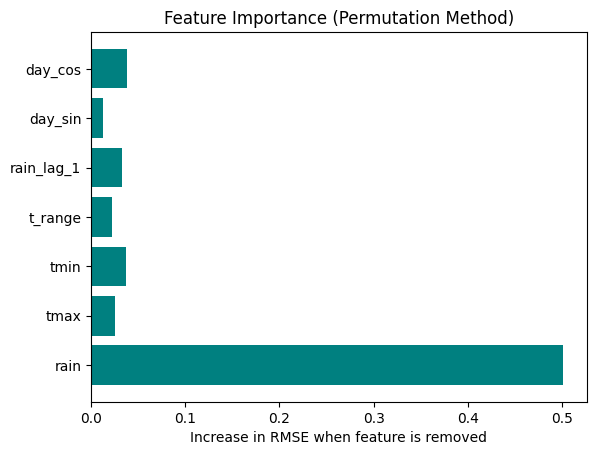

In [14]:
from sklearn.metrics import mean_squared_error

def get_permutation_importance(model, X_val, y_val, features):
    baseline_rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val).flatten()))
    importances = []

    for i in range(len(features)):
        X_temp = X_val.copy()
        # Shuffle the i-th feature across all sequences
        np.random.shuffle(X_temp[:, :, i])
        shuffled_rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_temp).flatten()))
        importances.append(shuffled_rmse - baseline_rmse)

    return importances

# Plot the results
importances = get_permutation_importance(model, X_val, y_val, features)
plt.barh(features, importances, color='teal')
plt.xlabel("Increase in RMSE when feature is removed")
plt.title("Feature Importance (Permutation Method)")
plt.show()

In [15]:
# Calculate Yearly Total Rainfall
yearly_rain = ds.rain.resample(time='YS').sum(dim=['time', 'lat', 'lon']).compute()

# Compare 1950s vs 2020s
avg_1950s = yearly_rain.sel(time=slice('1951', '1960')).mean().values
avg_2020s = yearly_rain.sel(time=slice('2015', '2024')).mean().values

percent_change = ((avg_2020s - avg_1950s) / avg_1950s) * 100

print(f"Average Yearly Rainfall (1950s): {avg_1950s:.2f} mm")
print(f"Average Yearly Rainfall (2020s): {avg_2020s:.2f} mm")
print(f"Detected Climatic Shift: {percent_change:.2f}% change over 70 years")

Average Yearly Rainfall (1950s): 5360795.00 mm
Average Yearly Rainfall (2020s): 5260583.50 mm
Detected Climatic Shift: -1.87% change over 70 years
